In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Credit Card Customer Data.csv")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

df.head()

Shape: (660, 7)
Missing values: 0
Duplicates: 0


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [3]:
df = df.drop_duplicates()

X = df.drop(columns=["Sl_No", "Customer Key"])

X = X.fillna(X.median())

X.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Explanation: Scaling gives every feature equal importance when calculating distances.

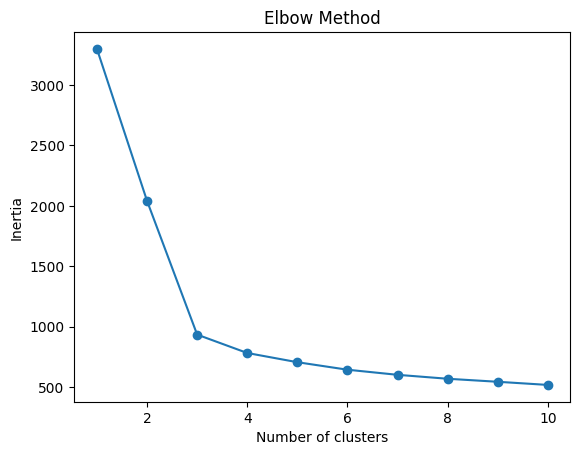

In [5]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Explanation: The elbow point shows where adding more clusters stops producing a large reduction in inertia.

For this dataset, the elbow will normally appear around k = 3.

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print(pd.Series(kmeans_labels).value_counts())

0    386
2    224
1     50
Name: count, dtype: int64


Explanation: K-Means separates customers into three clusters based on the elbow graph.

If your elbow graph clearly shows a different value, replace n_clusters=3 with that value.

In [7]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print(pd.Series(dbscan_labels).value_counts())

 0    606
-1     44
 1     10
Name: count, dtype: int64


Explanation: DBSCAN finds dense customer groups, and label -1 represents customers considered noise.

If DBSCAN marks almost every point as -1, increase eps slightly, such as 1.0. If it creates only one large cluster, reduce eps, such as 0.6.

In [8]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print(
    "Variance explained:",
    pca.explained_variance_ratio_.sum().round(3)
)

PCA shape: (660, 2)
Variance explained: 0.832


Explanation: PCA reduces the five customer features into two dimensions so the clusters can be plotted.

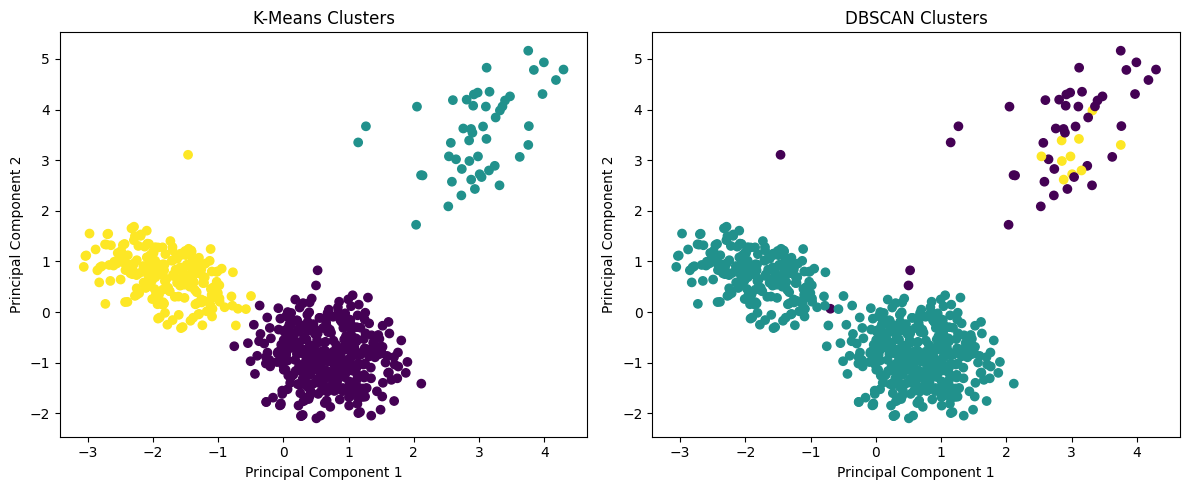

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis"
)
axes[0].set_title("K-Means Clusters")

axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis"
)
axes[1].set_title("DBSCAN Clusters")

for ax in axes:
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

Explanation: The two PCA scatter plots show how K-Means and DBSCAN group the same customers differently.

In [10]:
comparison = pd.DataFrame({
    "KMeans_Cluster": kmeans_labels,
    "DBSCAN_Cluster": dbscan_labels
})

print("K-Means groups:")
print(comparison["KMeans_Cluster"].value_counts())

print("\nDBSCAN groups:")
print(comparison["DBSCAN_Cluster"].value_counts())

print("\nNumber of DBSCAN noise points:")
print((dbscan_labels == -1).sum())

K-Means groups:
KMeans_Cluster
0    386
2    224
1     50
Name: count, dtype: int64

DBSCAN groups:
DBSCAN_Cluster
 0    606
-1     44
 1     10
Name: count, dtype: int64

Number of DBSCAN noise points:
44


Explanation: Compares the number and size of groups produced by both algorithms.

The elbow method suggested three K-Means clusters. K-Means assigned every customer to one of those three groups. DBSCAN created groups based on customer density and labelled unusual customers as -1. Therefore, the results differ because K-Means forces every point into a fixed number of clusters, while DBSCAN can find irregular groups and noise.